<a href="https://colab.research.google.com/github/josecamilocastrohernandez/urban-mobility-latam-analysis/blob/main/urban_mobility_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación de Movilidad Urbana y Productividad Económica en LATAM (2024)

Este proyecto analiza la interacción entre la eficiencia del transporte metropolitano y los indicadores macroeconómicos en las principales ciudades de América Latina. A través del procesamiento de registros telemáticos de TomTom Traffic Index y métricas socioeconómicas de la OECD, se construye un pipeline integral para estandarizar datos, evaluar niveles de congestión e identificar los nodos urbanos con mayor rezago en infraestructura.

## 1. Ingesta y Carga de Datos

En esta sección se importan las librerías analíticas (`pandas`, `numpy`, `seaborn`, `matplotlib`) y se cargan las fuentes de telemetría vial de TomTom Traffic Index y los indicadores socioeconómicos de la OECD para su inspección preliminar.

In [87]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
import os

# 1. Crear la carpeta /datasets
!mkdir -p /datasets

# 2. Mover el CSV de OECD si existe en /content
if os.path.exists('/content/oecd_city_economy.csv'):
    !mv /content/oecd_city_economy.csv /datasets/

# 3. Descomprimir TomTom si existe en /content
if os.path.exists('/content/tomtom_traffic.csv.gz'):
    !gzip -d -c /content/tomtom_traffic.csv.gz > /datasets/tomtom_traffic.csv

# 4. Verificar que ambos archivos existan
!ls -lh /datasets

total 142M
-rw-r--r-- 1 root root 1.8K Oct  8 19:52 oecd_city_economy.csv
-rw-r--r-- 1 root root 142M Oct  8 22:23 tomtom_traffic.csv


In [89]:
# cargar los archivos CSV
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [90]:
# mostrar las primeras 5 filas de cada DataFrame
print("--- Datos de Tráfico (TomTom) ---")
display(traffic.head())

--- Datos de Tráfico (TomTom) ---


,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [91]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


## 2. Diagnóstico Estructural y Exploración de Variables

En esta etapa se examinan la dimensionalidad, tipos de datos y consistencia de ambos conjuntos de datos para definir el plan de saneamiento y conversión antes de la integración relacional.

In [92]:
# Examinar la estructura de traffic
print("--- Estructura de Tráfico (TomTom) ---")
traffic.info()
print("\n--- Primeras 3 filas ---")
display(traffic.head(3))

--- Estructura de Tráfico (TomTom) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay               

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


### Diagnóstico de estructura: Dataset de Tráfico (`traffic`)

* **Volumen e integridad:** El conjunto de datos contiene 1.004.464 registros y 12 columnas, sin presencia de valores nulos en ninguna de sus variables (`non-null`).
* **Variables categóricas y temporales:** Las columnas geográficas (`Country`, `City`) y las marcas de tiempo (`UpdateTimeUTC`, `UpdateTimeUTCWeekAgo`) se encuentran almacenadas como tipo `object` (cadenas de texto).
* **Métricas operativas:** Los indicadores numéricos de congestión y tiempos de viaje (`JamsDelay`, `TrafficIndexLive`, `JamsLengthInKms`, `JamsCount`, `TrafficIndexWeekAgo`, `TravelTimeLivePer10KmsMins`, `TravelTimeHistoricPer10KmsMins` y `MinsDelay`) están correctamente tipificados como `float64`.
* **Transformaciones requeridas:** Es indispensable convertir las marcas de tiempo (`UpdateTimeUTC` y `UpdateTimeUTCWeekAgo`) a formato `datetime64` para habilitar el filtrado por año y la agregación temporal.

In [93]:
# Examinar la estructura de eco
print("--- Estructura de Economía (OECD) ---")
eco.info()
print("\n--- Primeras 3 filas ---")
display(eco.head(3))

--- Estructura de Economía (OECD) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB

--- Primeras 3 filas ---


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


### Diagnóstico de estructura: Dataset Económico (`eco`)

* **Volumen e integridad:** El conjunto de datos consta de 30 registros y 7 variables, sin valores nulos detectados (`non-null`).
* **Variables base:** La columna `Year` está registrada como entero (`int64`), mientras que las entidades geográficas (`City` y `Country`) se encuentran en formato de texto (`object`).
* **Inconsistencias de formato numérico:** Las variables cuantitativas (`City GDP/capita`, `Unemployment %`, `PM2.5 (μg/m³)` y `Population (M)`) venían mapeadas como `object` debido a separadores de miles, comas decimales y el símbolo `%`.
* **Tratamiento requerido:** Saneamiento tipográfico de cadenas y casteo explícito a tipo `float64` para habilitar el análisis estadístico y agregaciones cuantitativas.

### Estandarización de Nomenclatura (`snake_case`)

Se renombran las columnas de ambos conjuntos de datos bajo la convención estándar `snake_case` para prevenir errores de indexación, eliminar caracteres especiales y facilitar los cruces relacionales posteriores.

In [94]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={
    'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_in_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_per_10kms_mins',
    'MinsDelay': 'mins_delay'
})

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [95]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={
    'Year': 'year',
    'City': 'city',
    'Country': 'country',
    'City GDP/capita': 'city_gdp_capita',
    'Unemployment %': 'unemployment_percent',
    'PM2.5 (μg/m³)': 'pm2_5',
    'Population (M)': 'population_m'
})

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_percent',
       'pm2_5', 'population_m'],
      dtype='object')

### Saneamiento de Tipos de Datos y Conversión Numérica

Se realiza la conversión explícita de las marcas temporales en `traffic` a tipo `datetime64[ns]`. Paralelamente, en el conjunto socioeconómico `eco` se depuran los caracteres especiales (símbolos porcentuales y separadores de miles/decimales) para castear los indicadores a tipo de punto flotante (`float64`) y se deriva la variable de escala demográfica absoluta (`population`).

In [96]:


# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')

# verificar el cambio
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [97]:


# Limpia separadores y convierte columnas numéricas en eco
# Paso 1: GDP - Quitar puntos de miles y cambiar coma por punto decimal
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Paso 2: Desempleo - Quitar % y cambiar coma por punto
eco['unemployment_percent'] = eco['unemployment_percent'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Paso 3: Población en millones - Cambiar coma por punto
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Paso 4: Contaminación PM2.5 - Cambiar coma por punto
eco['pm2_5'] = eco['pm2_5'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1000000

# Verificar el cambio
eco.info()
display(eco.head(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  30 non-null     int64  
 1   city                  30 non-null     object 
 2   country               30 non-null     object 
 3   city_gdp_capita       30 non-null     float64
 4   unemployment_percent  30 non-null     float64
 5   pm2_5                 30 non-null     float64
 6   population_m          30 non-null     float64
 7   population            30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_percent,pm2_5,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0


## 3. Segmentación Temporal (Periodo 2024)

A partir de la marca de tiempo `update_time_utc`, se extrae la componente anual en el conjunto de tráfico para aislar y homogeneizar el periodo de análisis a **2024**, asegurando consistencia temporal con las métricas socioeconómicas de la OECD y evitando mutaciones en los DataFrames base mediante copias explícitas (`.copy()`).

In [98]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year



# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [99]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
print("--- Tráfico 2024 ---")
display(traffic_2024.head())

print("\n--- Economía 2024 ---")
display(eco_2024.head())


--- Tráfico 2024 ---


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024



--- Economía 2024 ---


,year,city,country,city_gdp_capita,unemployment_percent,pm2_5,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0


## 4. Agregación Espacial de Métricas Telemáticas

Dado que la base de tráfico cuenta con registros a nivel de intervalos diarios y horarios para múltiples zonas, se consolida la información mediante una agregación anual promedio agrupada por ciudad y país (`city`, `country`, `year`). Esto sintetiza las métricas operativas clave (`jams_delay`, índices de tráfico, conteo y longitud de embotellamientos, y tiempos de viaje) para un análisis comparativo representativo a nivel macro.

In [100]:
# Calcular los promedios de trafico por ciudad, país y año
columnas_metricas = [
    'jams_delay', 'traffic_index_live', 'jams_length_in_kms',
    'jams_count', 'mins_delay', 'travel_time_live_per_10kms_mins',
    'travel_time_historic_per_10kms_mins'
]

traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year'])[columnas_metricas].mean().reset_index()

# Mostrar resultado
display(traffic_city_year_2024.head())

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [101]:
# Ordenar para ver la ciudad con mayor retraso
display(traffic_city_year_2024.sort_values(["jams_delay"], ascending=False).head(10))

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
321,sao-paulo,BRA,2024,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810
156,istanbul,TUR,2024,1660.789019,45.614786,245.686252,411.145698,2.463699,19.982495,17.518796
159,jakarta,IDN,2024,1379.037135,30.419242,215.228820,295.492817,1.193300,18.098409,16.905109
268,paris,FRA,2024,1320.746822,29.313446,265.865975,324.405534,1.170884,17.658980,16.488097
201,los-angeles,USA,2024,1277.210458,30.446623,341.053551,321.732026,0.790893,13.429048,12.638155


### Identificación del Nodo Crítico de Tráfico (2024)

Al ordenar los registros consolidados por tiempo de demora (`jams_delay`), **Ciudad de México** se sitúa como el nodo más congestionado de la muestra global, promediando más de 2.833 minutos de retraso anual y superando ampliamente a otras megalópolis como Tokio, Nueva York y Londres.

## 5. Integración Relacional (Movilidad y Macroeconomía)

Se consolidan las fuentes mediante una unión relacional de tipo `INNER JOIN` utilizando como claves compuestas la ciudad y el año (`city`, `year`). Esto produce una matriz unificada que conserva únicamente aquellas urbes con métricas simultáneas de tráfico e indicadores económicos para el periodo 2024.

In [102]:
# Seleccionar columnas clave (Ajustadas a los nombres que definimos antes)
left_cols = [
    'city', 'country', 'year', 'jams_delay', 'traffic_index_live',
    'jams_length_in_kms', 'jams_count', 'mins_delay',
    'travel_time_live_per_10kms_mins', 'travel_time_historic_per_10kms_mins'
]

right_cols = [
    'city', 'year', 'city_gdp_capita', 'unemployment_percent', 'pm2_5', 'population'
]

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets (Inner Join por ciudad y año)
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_percent,pm2_5,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3700000.0


## 6. Análisis Exploratorio y Visualización de Relaciones

En esta etapa se analiza la distribución univariada de las variables críticas (la congestión vehicular mediante diagrama de caja y el PIB per cápita mediante histograma de frecuencias) para detectar asimetrías y valores atípicos antes de evaluar su correlación conjunta.

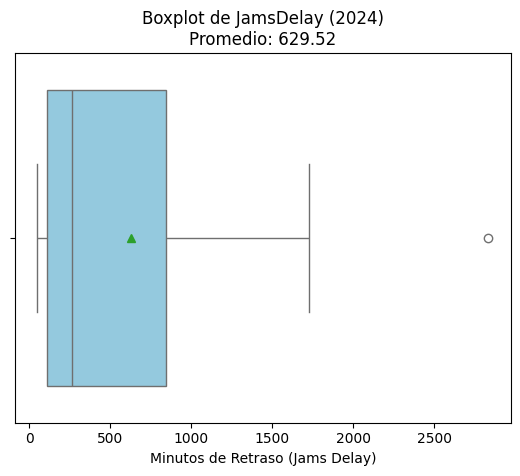

In [103]:

# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data=merged, x='jams_delay', showmeans=True, color='skyblue')

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.xlabel('Minutos de Retraso (Jams Delay)')
plt.show()


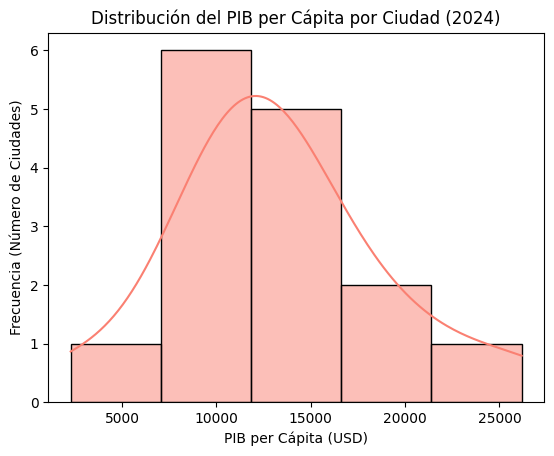

In [104]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
sns.histplot(data=merged, x='city_gdp_capita', bins=5, kde=True, color='salmon')

plt.title('Distribución del PIB per Cápita por Ciudad (2024)')
plt.xlabel('PIB per Cápita (USD)')
plt.ylabel('Frecuencia (Número de Ciudades)')
plt.show()


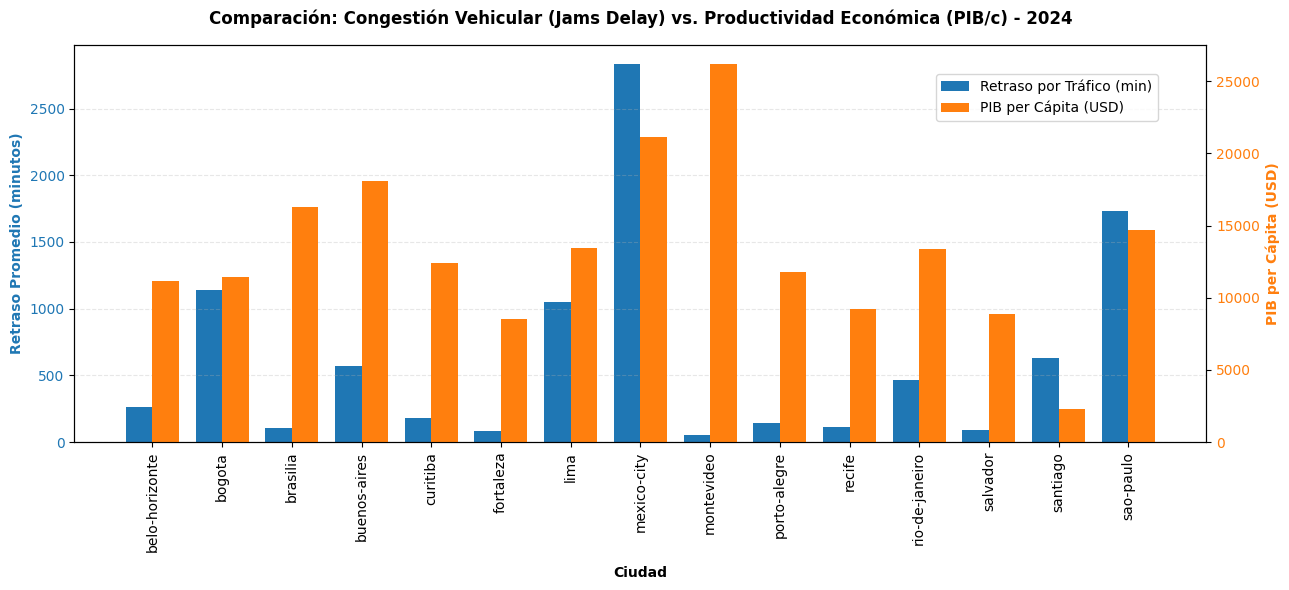

In [105]:
# Gráfico comparativo de doble eje: Retraso por Tráfico vs. PIB per Cápita por Ciudad
fig, ax1 = plt.subplots(figsize=(13, 6))

x = np.arange(len(merged['city']))
width = 0.38

# Eje 1 (Izquierda): Minutos de retraso por congestión
color1 = '#1f77b4'
ax1.bar(x - width/2, merged['jams_delay'], width, label='Retraso por Tráfico (min)', color=color1)
ax1.set_xlabel('Ciudad', fontweight='bold', labelpad=10)
ax1.set_ylabel('Retraso Promedio (minutos)', color=color1, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(x)
ax1.set_xticklabels(merged['city'], rotation=90)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Eje 2 (Derecha): PIB per cápita
ax2 = ax1.twinx()
color2 = '#ff7f0e'
ax2.bar(x + width/2, merged['city_gdp_capita'], width, label='PIB per Cápita (USD)', color=color2)
ax2.set_ylabel('PIB per Cápita (USD)', color=color2, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)

# Título y leyenda combinada
plt.title('Comparación: Congestión Vehicular (Jams Delay) vs. Productividad Económica (PIB/c) - 2024', fontweight='bold', pad=15)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88), frameon=True)

plt.tight_layout()
plt.show()

### Hallazgos de Correlación: Movilidad Urbana vs. Productividad Económica

Al evaluar la distribución cruzada entre congestión vehicular (`jams_delay`) y PIB per cápita (`city_gdp_capita`), se destacan los siguientes patrones estructurales:

* **Ausencia de correlación lineal directa:** Una mayor productividad económica no implica necesariamente un colapso en la movilidad. Casos como **Montevideo** evidencian que es viable sostener un PIB per cápita elevado (~26.000 USD) manteniendo niveles mínimos de retraso vial.
* **Valores atípicos extremos (Outliers):** **Ciudad de México** representa una anomalía regional crítica donde convergen una intensa actividad económica y niveles de congestión sin precedentes (superando los 2.800 minutos de retraso promedio).
* **Nodos críticos de infraestructura:** Ciudades como **Bogotá** y **São Paulo** presentan un desbalance preocupante: demoras severas frente a niveles de PIB moderados. En particular, la congestión en Bogotá opera como un freno directo a su competitividad regional, lo que valida la necesidad de priorizar inversión en transporte masivo en este nodo urbano.

## 7. Exportación del Dataset Consolidado

Se genera el archivo final procesado y estandarizado con todas las métricas de tráfico y variables macroeconómicas alineadas a nivel ciudad para el periodo 2024. Este archivo sirve como insumo estructurado para análisis posteriores o tableros de visualización.

In [106]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

print("✅ Archivo 'ladb_mobility_economy_2024_clean.csv' generado con éxito.")


✅ Archivo 'ladb_mobility_economy_2024_clean.csv' generado con éxito.


# Resumen Ejecutivo: Movilidad y Productividad en Ciudades de LATAM (2024)

### Contexto & Objetivo
Este análisis evalúa la relación entre la eficiencia de la movilidad urbana (medida a través del retraso por congestión, `jams_delay`) y la productividad económica (`city_gdp_capita`) en las principales metrópolis de América Latina. El objetivo es identificar si el tráfico actúa como un cuello de botella para el desarrollo económico, permitiendo priorizar inversiones en infraestructura de transporte donde el impacto en la productividad y el bienestar sea mayor.

### Cobertura de Datos & Metodología
* **Alcance:** El estudio se centró en el año 2024, analizando una muestra representativa de ciudades latinoamericanas (Ciudad de México, Bogotá, Buenos Aires, Montevideo, Santiago, São Paulo, entre otras).
* **Pipeline Técnico:**
  1. Estandarización de nombres bajo convención `snake_case`.
  2. Limpieza de formatos numéricos (remoción de símbolos y estandarización decimal) y conversión de fechas a `datetime64`.
  3. Agregación anual consolidada a partir de más de 1.000.000 de registros telemáticos de tráfico.
  4. Cruce relacional mediante `INNER JOIN` para unificar indicadores de movilidad y economía en una matriz validada mediante diagramas de caja e histogramas.

### Hallazgos Principales
* **Ausencia de correlación lineal directa:** La riqueza urbana no conlleva inevitablemente un colapso en la movilidad. Casos como **Montevideo** demuestran que es posible alcanzar una alta productividad (~26.000 USD/c) conservando niveles mínimos de retraso vial.
* **Valores atípicos extremos (Outliers):** **Ciudad de México** se consolida como una anomalía regional crítica, con niveles de congestión que superan los 2.800 minutos de retraso promedio anual a pesar de su elevado volumen económico.
* **Foco prioritario de inversión:** **Bogotá** presenta el desbalance más crítico de la muestra: retrasos severos frente a un PIB per cápita moderado (~11.400 USD). A diferencia de otras capitales con mayor capacidad fiscal, el tráfico en Bogotá actúa como un lastre directo para su competitividad regional.

### Recomendaciones
* Priorizar la estructuración y financiamiento de proyectos de transporte público masivo e infraestructura vial segregada en **Bogotá** y **Lima**, liberando su potencial productivo estancado.
* Diseñar políticas de movilidad activa y descentralización vial que eviten que ciudades intermedias en crecimiento repliquen el modelo de congestión de las megaciudades.